## Estudo de caso 1 : Detecção de fraude

In [55]:
import keras 
import datetime
import tensorflow as tf
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub

from sklearn.metrics import *

In [2]:
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

In [3]:
data = pd.read_csv(path + "/creditcard.csv")

In [4]:
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
data.dtypes

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Verificando valores unicos

In [6]:
subset = round(data.nunique() / data.shape[0],2).reset_index()
# Modificando para cat
subset['cat_por'] = subset[0].astype(str)

# 
subset.groupby('cat_por')['index'].apply(lambda x: x.tolist()).reset_index()

,cat_por,index
0,0.0,[Class]
1,0.12,[Amount]
2,0.44,[Time]
3,0.97,"[V1, V2, V3, V4, V5, V6, V7, V8, V9, V10, V11,..."


Verificando a proporção do label

In [7]:
subset = data['Class'].value_counts().reset_index(name='count')
subset['porcentagem'] = subset['count']/data.shape[0]

In [8]:
subset

,Class,count,porcentagem
0,0,284315,0.998273
1,1,492,0.001727


Fazendo o pairplot, levando em consideração a proporção será uma amostra que manterá a classe com menor quantidade

In [9]:
subset_0 = data[data['Class'] == 0].sample(n=1000, random_state=1)
subset_1 = data[data['Class'] == 1]
subset = pd.concat([subset_0, subset_1])

In [10]:
lista_col = subset.columns.tolist()
lista_col.remove('Class')

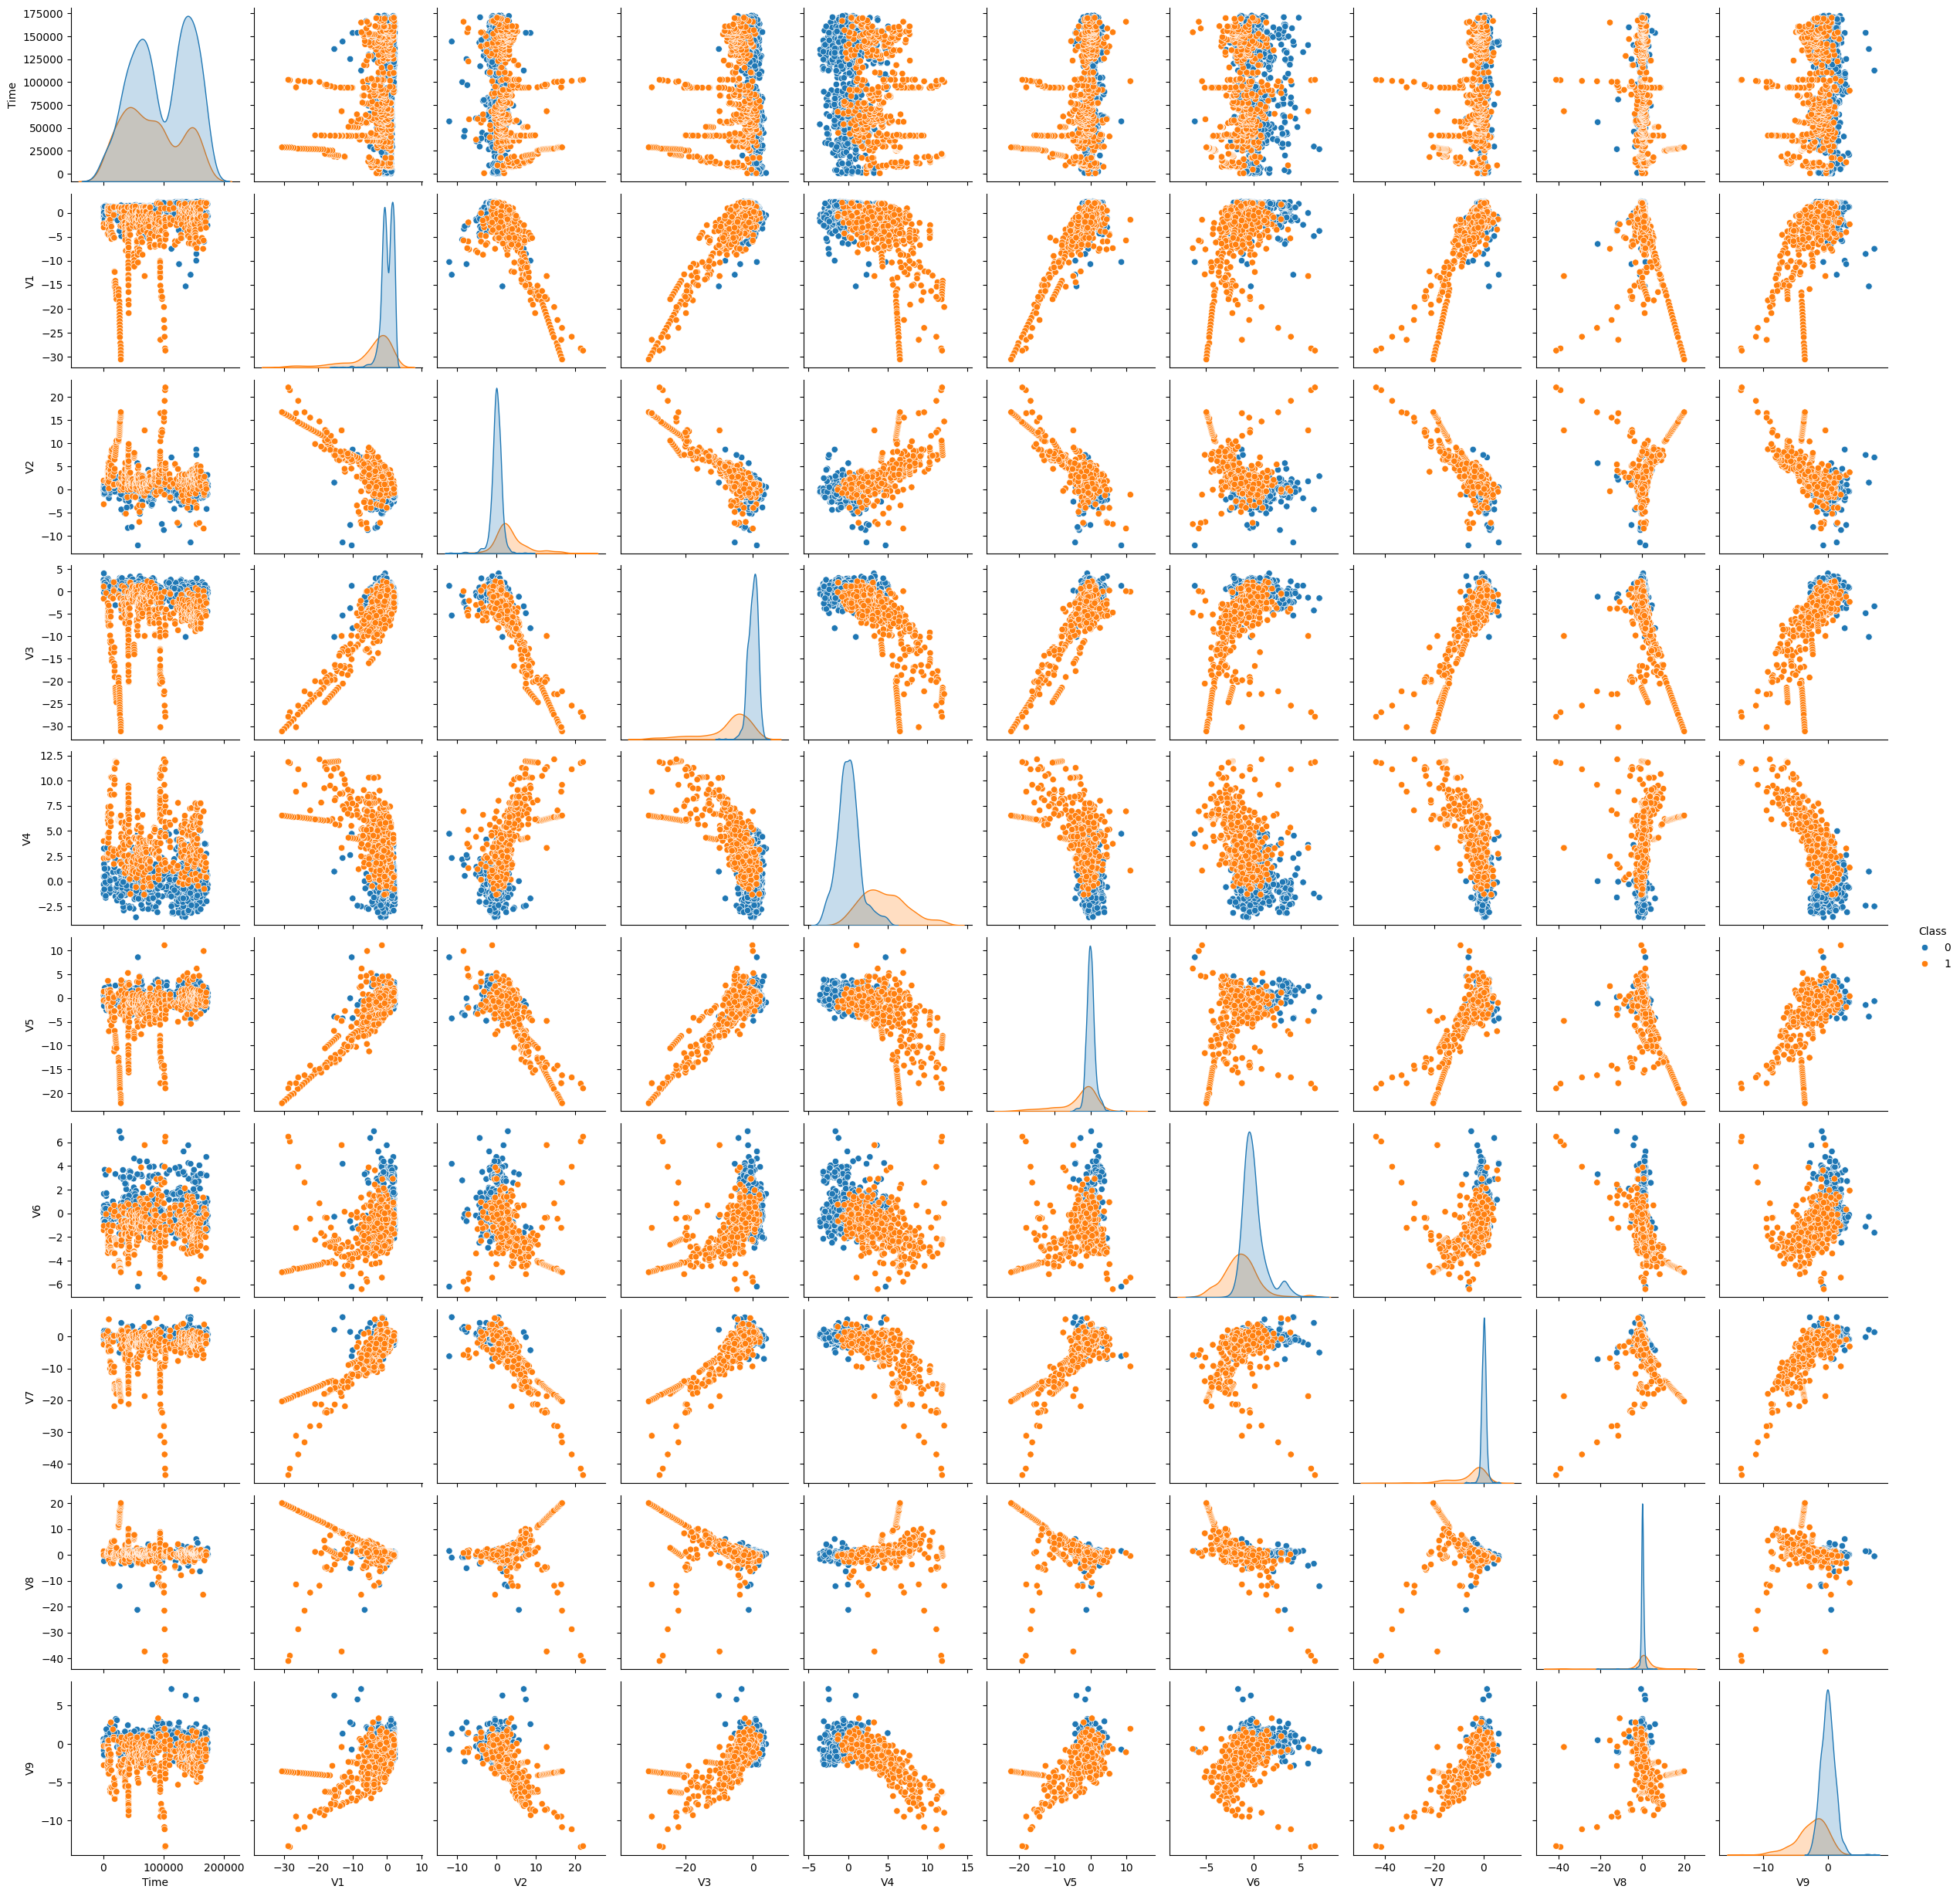

In [11]:
sns.pairplot(subset[lista_col[0:10]+['Class']], hue='Class')

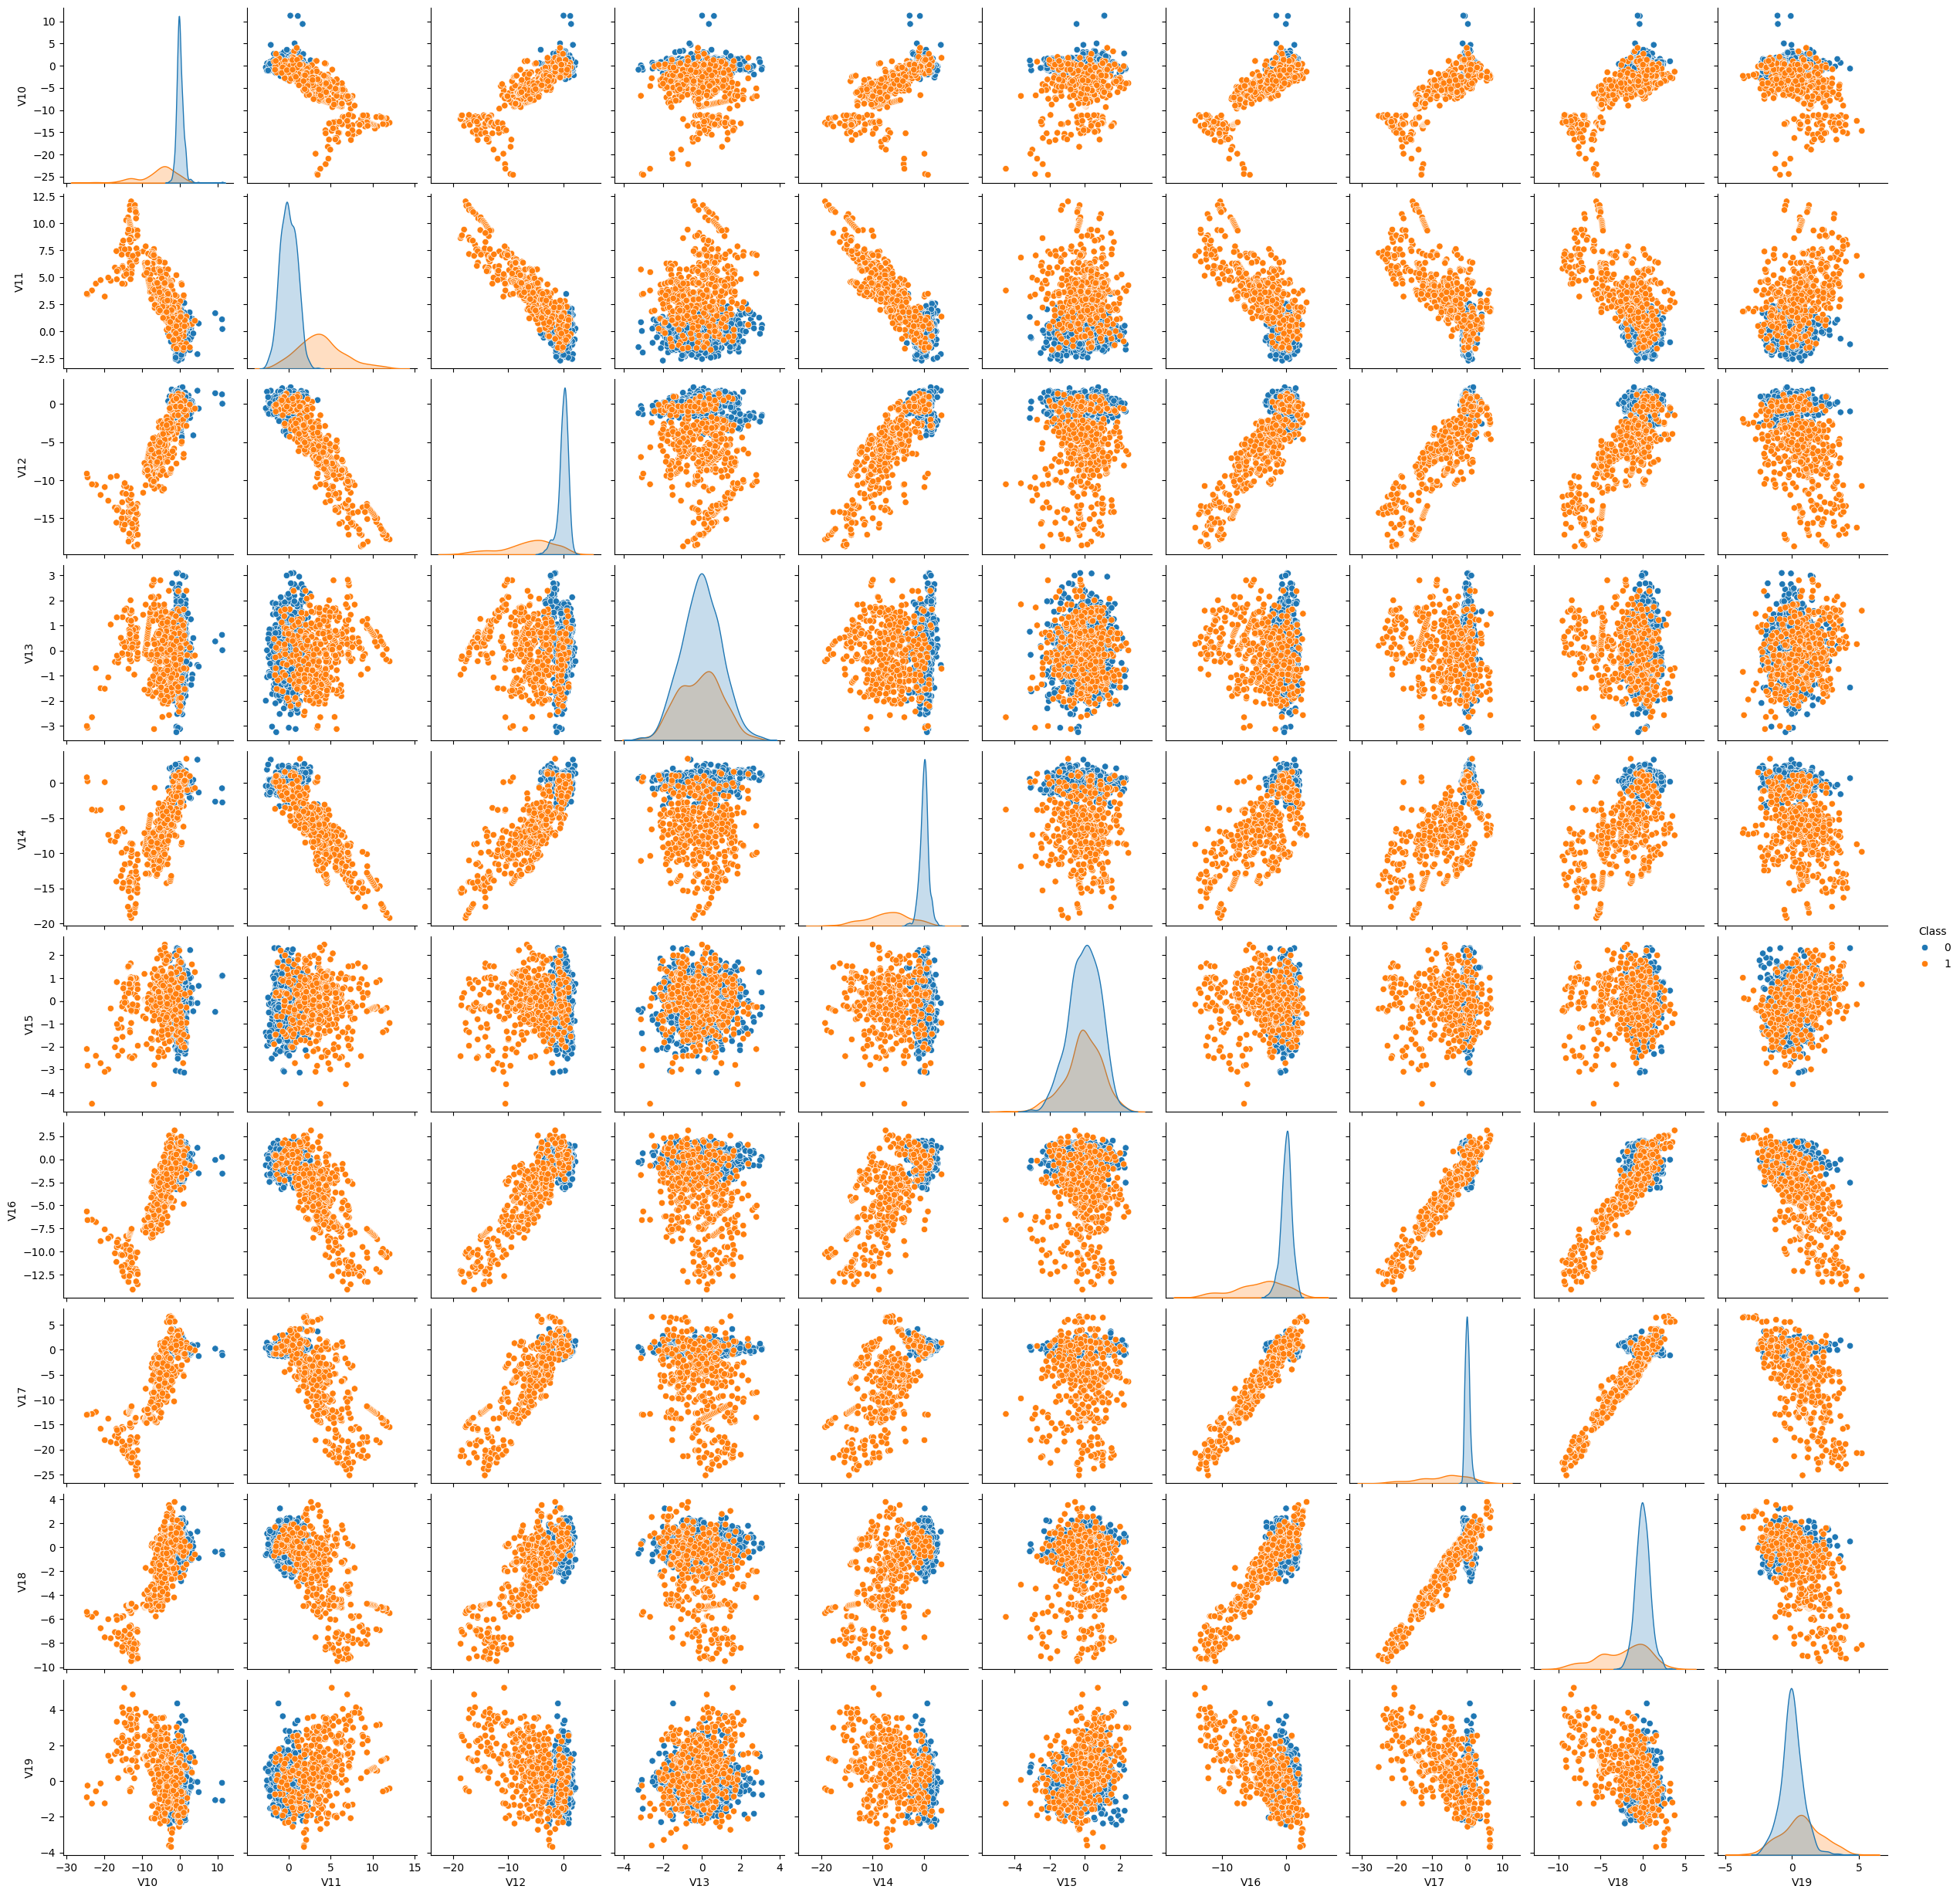

In [12]:
sns.pairplot(subset[lista_col[10:20]+['Class']], hue='Class')

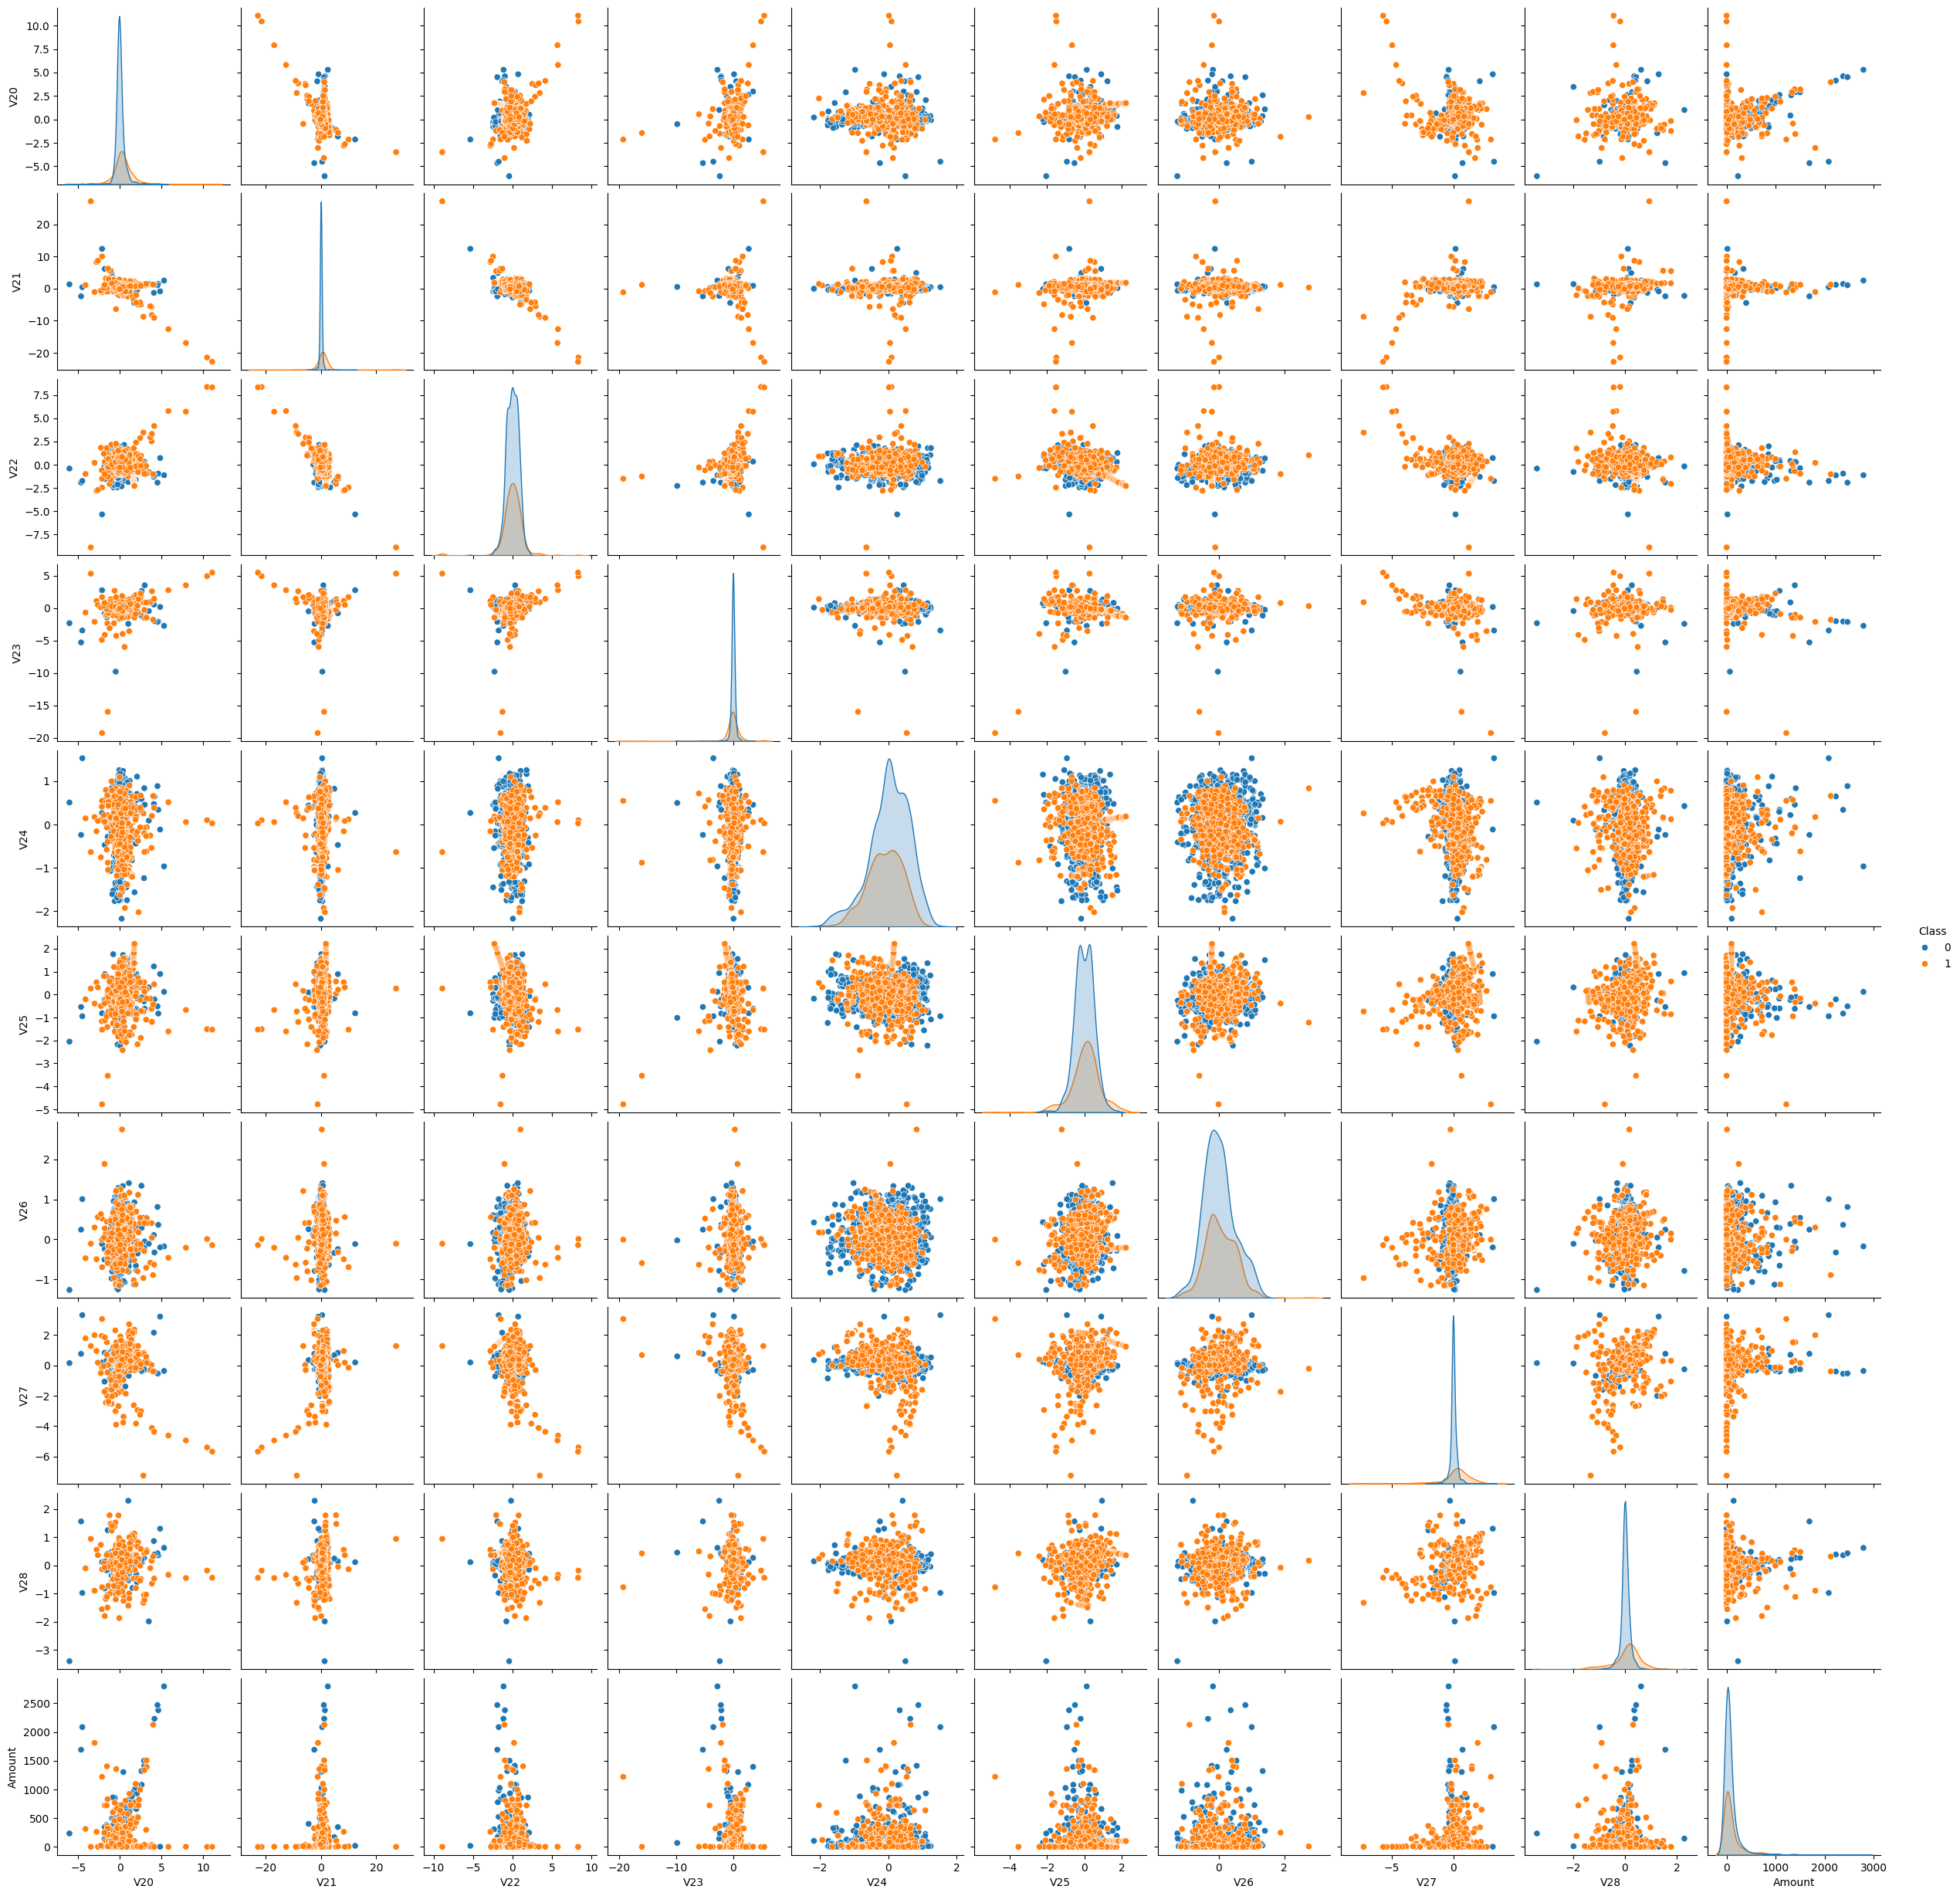

In [13]:
sns.pairplot(subset[lista_col[20:30]+['Class']], hue='Class')

In [14]:
data.corrwith(data['Class'])

Time     -0.012323
V1       -0.101347
V2        0.091289
V3       -0.192961
V4        0.133447
V5       -0.094974
V6       -0.043643
V7       -0.187257
V8        0.019875
V9       -0.097733
V10      -0.216883
V11       0.154876
V12      -0.260593
V13      -0.004570
V14      -0.302544
V15      -0.004223
V16      -0.196539
V17      -0.326481
V18      -0.111485
V19       0.034783
V20       0.020090
V21       0.040413
V22       0.000805
V23      -0.002685
V24      -0.007221
V25       0.003308
V26       0.004455
V27       0.017580
V28       0.009536
Amount    0.005632
Class     1.000000
dtype: float64

In [15]:
subset = data.corrwith(data['Class'])
result = subset[(subset>-0.01) & (subset<0.01)]

In [16]:
result

V13      -0.004570
V15      -0.004223
V22       0.000805
V23      -0.002685
V24      -0.007221
V25       0.003308
V26       0.004455
V28       0.009536
Amount    0.005632
dtype: float64

> Colunas com correlação muito proximode 0 serão removidas

In [17]:
data = data.drop(columns=result.index)

## Criando modelo

In [18]:
from rich.progress import Progress

In [19]:
import pyprind
import tensorboard
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing   import StandardScaler

In [20]:
scale = StandardScaler()

In [21]:
X = data.drop(columns='Class').values.astype(np.float32)
X = scale.fit_transform(X)

y = data['Class'].values.reshape(-1, 1).astype(np.float32)

In [22]:
xtrain, xtest, ytrain, ytest = train_test_split(X, y, test_size=0.20, random_state=1, stratify=y)

In [23]:
train_data = tf.data.Dataset.from_tensor_slices((xtrain, ytrain), name='dados_treinamento')
train_data

<_TensorSliceDataset element_spec=(TensorSpec(shape=(21,), dtype=tf.float32, name=None), TensorSpec(shape=(1,), dtype=tf.float32, name=None))>

Criando modelo no `tf.module`

In [24]:
class models(tf.Module):
    def __init__(self, name=None, input_shape=[1, 1], random_seed=1):
        super(models, self).__init__(name=name)
        tf.random.set_seed(seed=random_seed)
        
        random = tf.random.normal(shape=input_shape, dtype=tf.float32)
        self.coef = tf.Variable(random, dtype=tf.float32, name="coef", trainable=True)
        self.bias = tf.Variable([0.0], dtype=tf.float32, name="bias", trainable=True)
        
    def __call__(self, x):
        return tf.matmul(x, self.coef) + self.bias

    def predict(self, x):
        return tf.nn.sigmoid(self(x))

In [25]:
(xtrain.shape[0] // 800)

284

In [ ]:
def train(xtrain, ytrain, input_shape, epochs=10, batch_size=32, random_seed=1, optimizer=None, losses=None, metrics=None):
    # Create model
    model   = models(name='SGD', input_shape=input_shape, random_seed=random_seed)

    # 
    train_data = tf.data.Dataset.from_tensor_slices((xtrain, ytrain), name='dados_treinamento')
    train_data = train_data.batch(batch_size=batch_size, drop_remainder=True)

    pgbar = pyprind.ProgBar(epochs, bar_char='-', monitor=True)

    for epoch in range(epochs):
        for xi, yi in train_data:
            with tf.GradientTape() as tape:
                ypred = model.predict(xi)
                loss  = losses(yi, ypred)
            # Calcula o gradiente
            gradient = tape.gradient(loss, model.trainable_variables)
            # Aplica o gradiente
            optimizer.apply_gradients(zip(gradient, model.trainable_variables))

        # Calcula a acurácia
        for i in metrics: i.update_state(ytrain, model.predict(xtrain))

        pgbar.update(
            1, 
            item_id=f'Epoch {epoch+1} - loss: {loss:.4f} - {' '.join([f'{i.name}: {i.result():.4f}' for i in metrics])}'
        )
        # Reseta das metricas
        for i in metrics: i.reset_states()
        
    return model

In [49]:
model = train(
    xtrain=xtrain,
    ytrain=ytrain,
    input_shape=[xtrain.shape[1], 1], 
    epochs=10, 
    batch_size=500, 
    random_seed=1, 
    optimizer=keras.optimizers.Adam(), 
    losses   =keras.losses.BinaryCrossentropy(), 
    metrics=[keras.metrics.BinaryAccuracy()]
)

0% [----------] 100% | ETA: 00:00:00 | Item ID: Epoch 10 -  loss: 0.0530 - binary_accuracy: 0.9468
Total time elapsed: 00:03:18


In [79]:
pred_test = (model.predict(xtest) > 0.5).numpy().astype(np.float32)

In [80]:
print(classification_report(ytest, pred_test))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     56864
         1.0       0.91      0.69      0.79        98

    accuracy                           1.00     56962
   macro avg       0.95      0.85      0.89     56962
weighted avg       1.00      1.00      1.00     56962



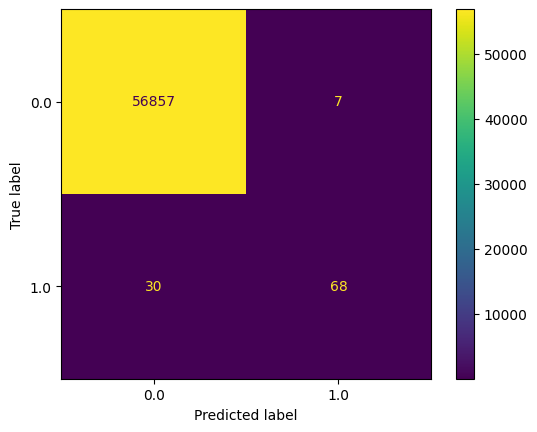

In [81]:
ConfusionMatrixDisplay.from_predictions(ytest, pred_test)

In [82]:
pred_train = (model.predict(xtrain) > 0.5).numpy().astype(np.float32)

In [83]:
print(classification_report(ytrain, pred_train))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    227451
         1.0       0.86      0.56      0.68       394

    accuracy                           1.00    227845
   macro avg       0.93      0.78      0.84    227845
weighted avg       1.00      1.00      1.00    227845



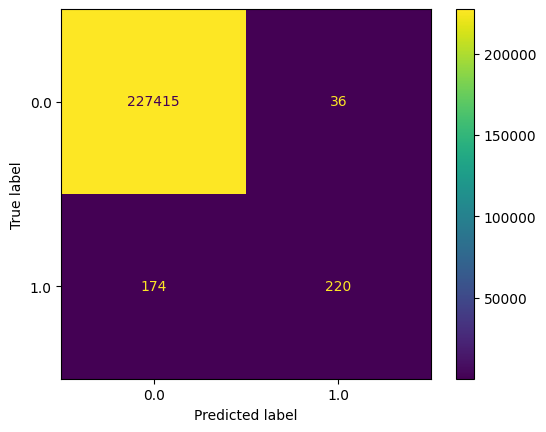

In [84]:
ConfusionMatrixDisplay.from_predictions(ytrain, pred_train)

Usando xgboost

In [70]:
import xgboost as xgb

In [73]:
xgboost_ = xgb.XGBClassifier()
xgboost_.fit(xtrain, ytrain)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [54]:
keras.metrics.BinaryAccuracy()(ytrain, xgboost_.predict(xtrain))

<tf.Tensor: shape=(), dtype=float32, numpy=0.999991238117218>

In [59]:
print(classification_report(ytrain, xgboost_.predict(xtrain)))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    227451
         1.0       1.00      1.00      1.00       394

    accuracy                           1.00    227845
   macro avg       1.00      1.00      1.00    227845
weighted avg       1.00      1.00      1.00    227845



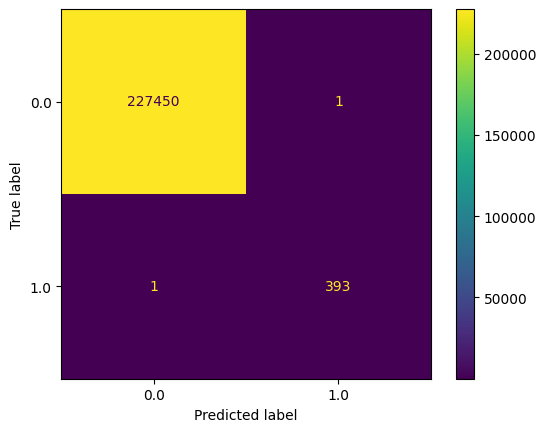

In [60]:
ConfusionMatrixDisplay.from_estimator(xgboost_, xtrain, ytrain)
plt.show()

In [86]:
print(classification_report(ytest, xgboost_.predict(xtest)))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     56864
         1.0       0.87      0.84      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962



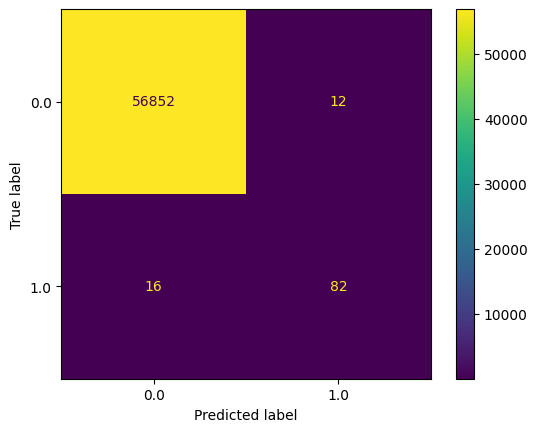

In [85]:
ConfusionMatrixDisplay.from_estimator(xgboost_, xtest, ytest)

In [ ]:
strat_kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=1)

metrics_acu = []
for train_index, test_index in strat_kfold.split(xtrain, ytrain):
    xtrain_kfold, xtest_kfold = xtrain[train_index], xtrain[test_index]
    ytrain_kfold, ytest_kfold = ytrain[train_index], ytrain[test_index]

    model_fold = xgb.XGBClassifier()
    model_fold.fit(xtrain_kfold, ytrain_kfold)
    metrics_acu.append(accuracy_score(ytest_kfold, model_fold.predict(xtest_kfold)))

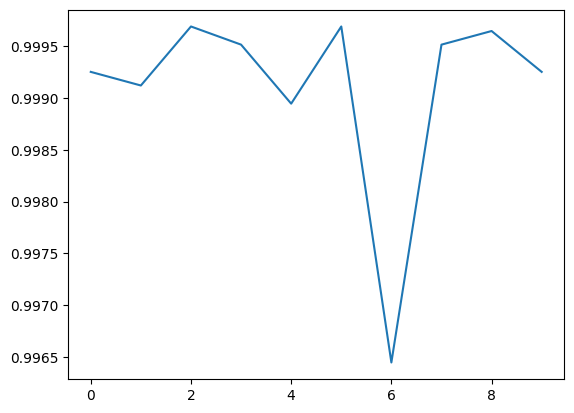

In [65]:
plt.plot(metrics_acu)
plt.show()

In [67]:
np.mean(metrics_acu)

np.float64(0.9991090390940718)

Encontrando melhor hyperparametros

In [68]:
from sklearn.model_selection import GridSearchCV

In [74]:
param_grid = {
    'max_depth': [2, 4, 6],
    'learning_rate': [0.1, 0.2, 0.3],
    'n_estimators': [100, 200]
}
grid_search = GridSearchCV(estimator=xgboost_, param_grid=param_grid, cv=5, n_jobs=-1, verbose=1)
grid_search.fit(xtrain, ytrain)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'learning_rate': [0.1, 0.2, ...], 'max_depth': [2, 4, ...], 'n_estimators': [100, 200]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [75]:
grid_search.best_score_

np.float64(0.9994996598564814)

In [76]:
grid_search.best_params_

{'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200}